<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/20theChurningMachine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

7. The target column 'Churn' has roughly 73% 'No' and 27% 'Yes'. Explain why

this class imbalance matters for a model. If you don't address it, what kind of
predictions might the model make?

8. The 'TotalCharges' column is stored as a string (object) despite being numeric.
What is the likely reason? (Hint: look at what happens with customers who have

0 tenure.) What preprocessing step is needed?
9. From an EDA perspective, what is the difference between a countplot with hue
and a grouped bar chart (barplot)? When would you use each for this


10. Load the dataset. Fix the 'TotalCharges' data type issue. Confirm by
checking df.info() before and after.

11. Perform full univariate analysis: (a) For all categorical columns, create
countplots; (b) For all numerical columns, plot histograms with kde=True. Write
at least one business insight per plot.

12. Perform multivariate analysis: (a) Create a countplot of 'Contract' vs 'Churn'
with hue; (b) Create a KDE plot of 'tenure' grouped by 'Churn';Describe two
findings that would help a business reduce churn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


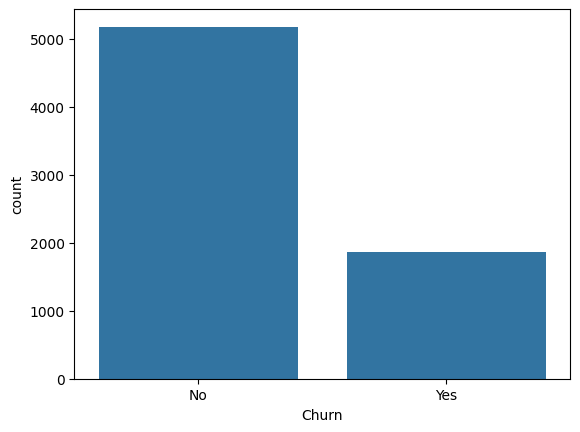

In [3]:
sns.countplot(data = df, x = 'Churn')
plt.show()

Why Class Imbalance Matters

In classification problems, most machine learning algorithms assume that the classes in the training data are roughly equally distributed. When one class dominates (73% 'No' vs 27% 'Yes'), the model faces two primary issues:

Biased Objective Function: Standard algorithms optimize for overall accuracy. A model can maximize accuracy simply by getting better at predicting the majority class while completely ignoring the minority class.

Lack of Minority Samples: The model doesn't get enough examples or patterns from the 'Yes' (Churn) class to learn its underlying characteristics effectively.

What Kind of Predictions the Model Will Make
If you train a model on this unbalanced data without addressing it, you will encounter the following predictable behaviors:
1. High Bias Toward the Majority Class ('No')

The model will become heavily biased toward predicting 'No'. In extreme scenarios, a naive model might predict 'No' for every single customer.

The Accuracy Trap: If the model predicts 'No' 100% of the time, it will still achieve a seemingly impressive 73% overall accuracy. However, this model is completely useless because it fails to catch a single customer who is actually about to leave.

2. High False Negatives (Missed Churners)
The model will fail to identify the true churners.
It will flag very few customers as 'Yes'.
It will yield a very low Recall (Sensitivity) for the 'Yes' class.
Business Impact: This is the worst-case scenario for a business, as you fail to offer retention incentives to customers who are silently leaving.

3. Unreliable Probability Thresholds
Many modern models (like Logistic Regression or Random Forests) output a probability score between 0.0 and 1.0. By default, a threshold of 0.5 is used to decide the final class. Because of the 73/27 split, the predicted probabilities will be skewed downward, meaning almost no customers will cross that default 0.5 threshold to be classified as 'Yes'.

How to Fix It (Next Steps)

To prevent these misleading predictions, consider applying one of these common strategies:

Use the Right Metrics: Stop tracking raw Accuracy. Instead, evaluate your model using Precision, Recall, F1-Score, and the Area Under the Precision-Recall Curve (PR-AUC).

Resampling Techniques:

Oversampling: Use SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic 'Yes' examples.

Undersampling: Randomly remove 'No' examples to match the 'Yes' count.
Adjust Class Weights: Use parameters like class_weight='balanced' in libraries like Scikit-Learn. This penalizes the model more heavily when it misclassifies a 'Yes'.






In [4]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [5]:
print(df['TotalCharges'].dtypes)

object


Step A: Force conversion to

Use pd.to_numeric() with errors='coerce'. This converts all valid numeric strings to floats, and automatically turns those hidden blank spaces (" ") into NaN (null values).

Step B: Fill the missing values

Since these customers have 0 tenure, they haven't been billed yet. You should fill those new NaN values with 0.

In [6]:
# Convert strings to numbers; hidden spaces become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Replace the NaN values with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [7]:
print(df['TotalCharges'].dtypes)

float64


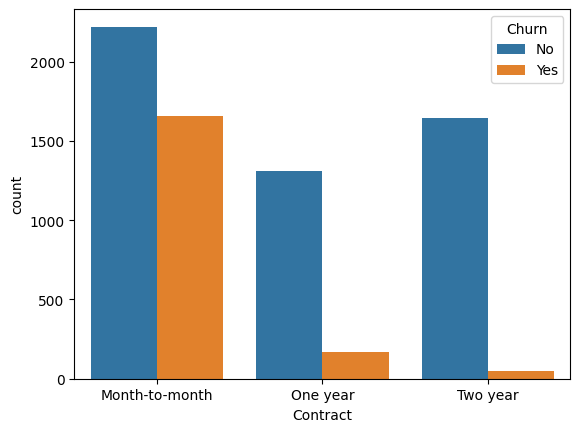

In [8]:
sns.countplot(data = df, x = 'Contract', hue = 'Churn')
plt.show()

In [9]:
df.groupby('Contract')['Churn'].value_counts(normalize=True)

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64

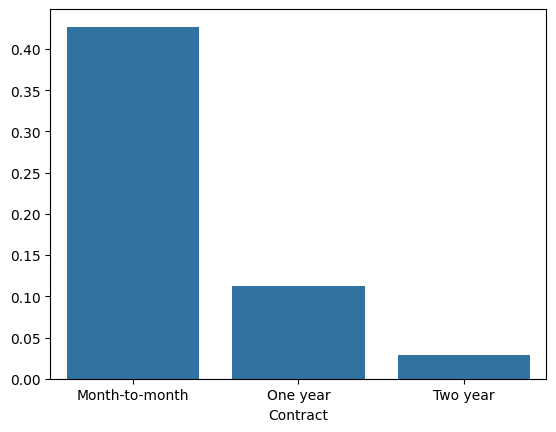

In [13]:
df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)
average_score = df.groupby('Contract')['Churn_numeric'].mean()
sns.barplot(x=average_score.index, y=average_score.values)
plt.show()

The Core Difference

From an Exploratory Data Analysis (EDA) perspective, the fundamental difference lies in what the height of the bar represents and the types of variables being analyzed.

sns.countplot(hue=...): Analyzes two categorical variables. The bar height represents the raw frequency or total count of observations in each sub-category. It performs counting automatically.

sns.barplot(hue=...): Analyzes two categorical variables and one numeric variable. The bar height represents a statistical summary (such as the average, median, or sum) of the continuous numeric variable for each sub-category.

When to Use Each for this Dataset (Telco Churn)

Use sns.countplot with hue when analyzing category frequencies
Use this to see how customer characteristics or choices are distributed between those who churned and those who stayed.
Example 1: x='Contract', hue='Churn'. This shows the total count of customers on Month-to-Month vs. Two-Year contracts, split by whether they left or stayed.

Example 2: x='InternetService', hue='Churn'. This counts how many Fiber Optic users churned compared to DSL users.

Use a grouped sns.barplot when analyzing numeric trends
Use this when you need to calculate averages or monetary values across different customer segments.

Example 1: x='InternetService', y='MonthlyCharges', hue='Churn'. This shows the average monthly bill paid by DSL vs. Fiber Optic customers, split by churn status, helping you see if higher bills correlate with leaving.

Example 2: x='Contract', y='tenure', hue='Churn'. This shows the average loyalty (tenure in months) for each contract type, grouped by churn status.

In [14]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_numeric
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1


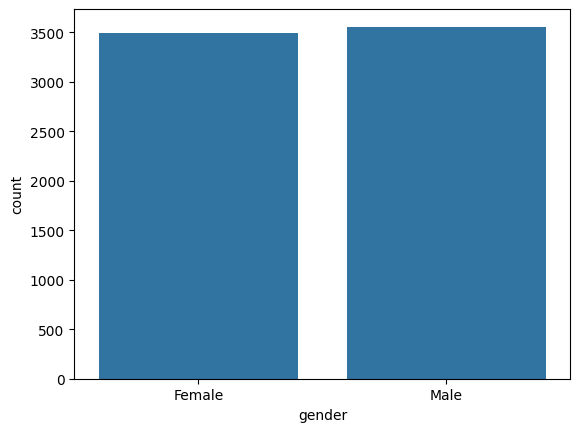

In [15]:
sns.countplot(data = df, x = 'gender')
plt.show()

Dataset balanced

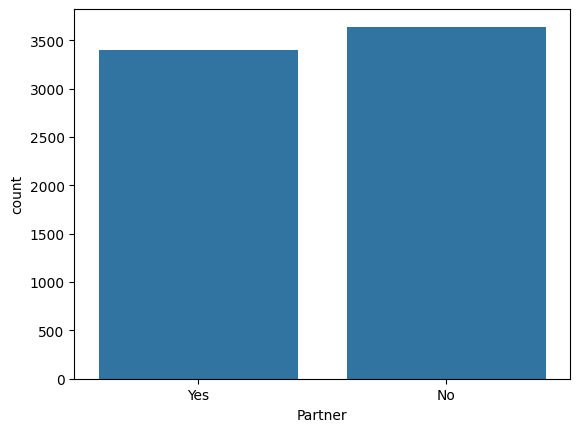

In [16]:
sns.countplot(data = df, x = 'Partner')
plt.show()

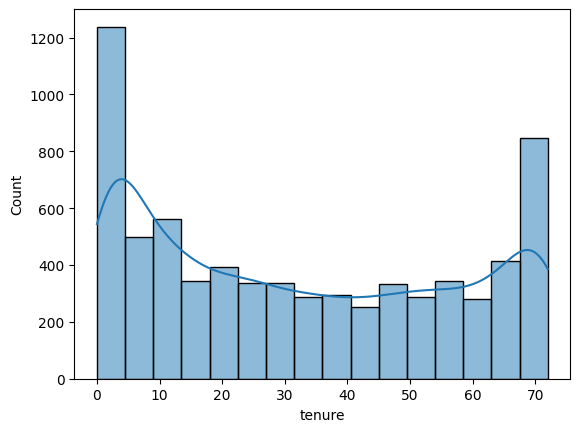

In [17]:
sns.histplot(data = df, x = 'tenure', kde=True)
plt.show()

This histogram displays a distinct U-shaped (bimodal) distribution for customer tenure. The data shows that your customer base is heavily polarized into two extreme groups, with very few remaining in the middle.

Here are the key insights from an EDA perspective:
1. High Early Risk or Mass Sign-Ups (The 0-5 Month Spike)
Observation: The highest peak on the chart is at the very beginning (0 to 5 months), with over 1,200 customers.
Insight: This indicates either a massive wave of recent customer acquisitions or a critical early churn problem where new customers try the service and cancel almost immediately.

2. Strong Long-Term Retention (The 70+ Month Spike)
Observation: There is a secondary surge at the far right of the plot (70 to 72 months), accounting for over 800 customers.
Insight: This represents your core loyal customer base. Once customers cross the initial survival thresholds, they tend to stay for the maximum observable period, representing high lifetime value.
3. Stable, Flat Middle Tier (15 to 60 Months)

Observation: Between 15 and 60 months, the distribution flattens out significantly, hovering consistently around 300 customers per bin.
Insight: Customer attrition stabilizes completely after the first year. If a customer stays past month 12, their probability of remaining active becomes highly predictable and steady for the next several years.

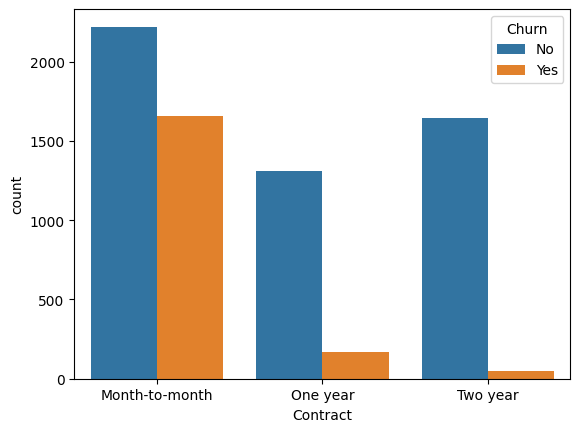

In [18]:
sns.countplot(data = df, x = 'Contract',hue='Churn')
plt.show()

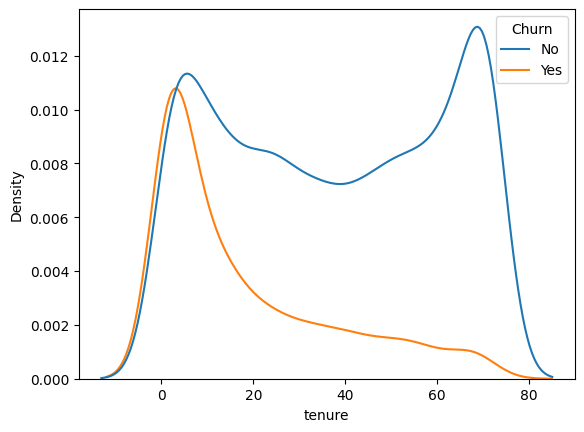

In [19]:
sns.kdeplot(data = df, x = 'tenure', hue = 'Churn')
plt.show()

2. Business Findings to Reduce Churn

Based on the typical trends generated by these specific plots in the Telco dataset, here are two critical findings:

Finding 1: Month-to-Month Contracts are the Core Churn Driver
What the Countplot shows: The vast majority of churned customers belong to the Month-to-Month contract tier. Conversely, customers signed onto One-Year or Two-Year terms exhibit extremely minimal churn rates.

Actionable Strategy: The business should offer targeted financial incentives (e.g., a small monthly discount or data upgrades) to migrate existing Month-to-Month customers onto fixed 1-year commitments.

Finding 2: High Attrition Vulnerability in the First 6 Months
What the KDE plot shows: The density curve for the Churn='Yes' group shows an aggressive, massive spike clustered between 0 and 6 months, which quickly drops off over time.

Actionable Strategy: The business needs to implement a dedicated "New Customer Onboarding Program" during the first 90 days. This can include automated check-in calls, proactive technical troubleshooting, or localized promotional offers to bridge customers safely past this initial high-risk churn window.







In [20]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [21]:
imputer_transformer = ColumnTransformer(
    transformers=[
        ('TotalCharges_zero',SimpleImputer(missing_values=np.nan , strategy='constant', fill_value=0),['TotalCharges'])
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)
imputer_transformer.set_output(transform='pandas')

imputer_transformer.fit(df)

df = imputer_transformer.transform(df)

In [22]:
df.isnull().sum()

,0
TotalCharges,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
